In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['figure.figsize'] = (24, 8)
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading (Full Market Dataset)
def load_all_data():
    all_data = []
    files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
    print(f"Found {len(files)} total stock files. Loading the entire market...")
    
    for file_path in files:
        symbol = os.path.basename(file_path).replace('.csv', '')
        try:
            df = pd.read_csv(file_path)
            df = df.dropna(subset=['Close'])
            
            # Basic Price Filter: We only want stocks that were actively trading between 50 and 5000 Rs
            if len(df) > 0:
                latest_price = df['Close'].iloc[-1]
                if latest_price < 50 or latest_price > 5000:
                    continue
                    
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date').reset_index(drop=True)
            
            # Anomaly Filter
            df['Daily_Ret'] = df['Close'].pct_change()
            df = df[(df['Daily_Ret'].isna()) | (df['Daily_Ret'].abs() <= 0.20)]
            
            df['Symbol'] = symbol
            all_data.append(df)
        except Exception as e:
            pass
            
    print(f"Successfully loaded and cleaned {len(all_data)} stocks.")
    return pd.concat(all_data, ignore_index=True)

data = load_all_data()


Found 1042 total stock files. Loading the entire market...


Successfully loaded and cleaned 947 stocks.


In [3]:
# 3. Apply the Champion Rules
LOOKBACK = 34
HOLD_DAYS = 13
ENTRY_ER = 0.6
AVOID_WMA = 0.03
TEST_START = '2023-01-01'

def apply_strategy(df):
    df = df.copy()
    
    # Forward Return
    df['Fwd_Ret'] = df['Close'].shift(-HOLD_DAYS) / df['Close'] - 1
    
    # ER
    change = abs(df['Close'] - df['Close'].shift(LOOKBACK))
    volatility = df['Close'].diff().abs().rolling(LOOKBACK).sum()
    df['ER'] = change / volatility
    
    # WMA Distance
    weights = np.arange(1, LOOKBACK + 1)
    df['WMA'] = df['Close'].rolling(LOOKBACK).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
    df['WMA_Dist'] = (df['Close'] - df['WMA']) / df['WMA']
        
    return df

print("Calculating strategy conditions across the entire market... (This may take a minute)")
_data_list = []
for sym, grp in data.groupby('Symbol'):
    _data_list.append(apply_strategy(grp))
data = pd.concat(_data_list, ignore_index=True).dropna(subset=['Fwd_Ret', 'ER', 'WMA_Dist'])
print("Calculations complete!")

# 1. Filter down to strictly UNSEEN 2023+ Data
test_data = data[data['Date'] >= TEST_START]

# 2. Extract the trades where our Champion conditions were met
champion_trades = test_data[(test_data['ER'] > ENTRY_ER) & (test_data['WMA_Dist'] < AVOID_WMA)]


Calculating strategy conditions across the entire market... (This may take a minute)


Calculations complete!


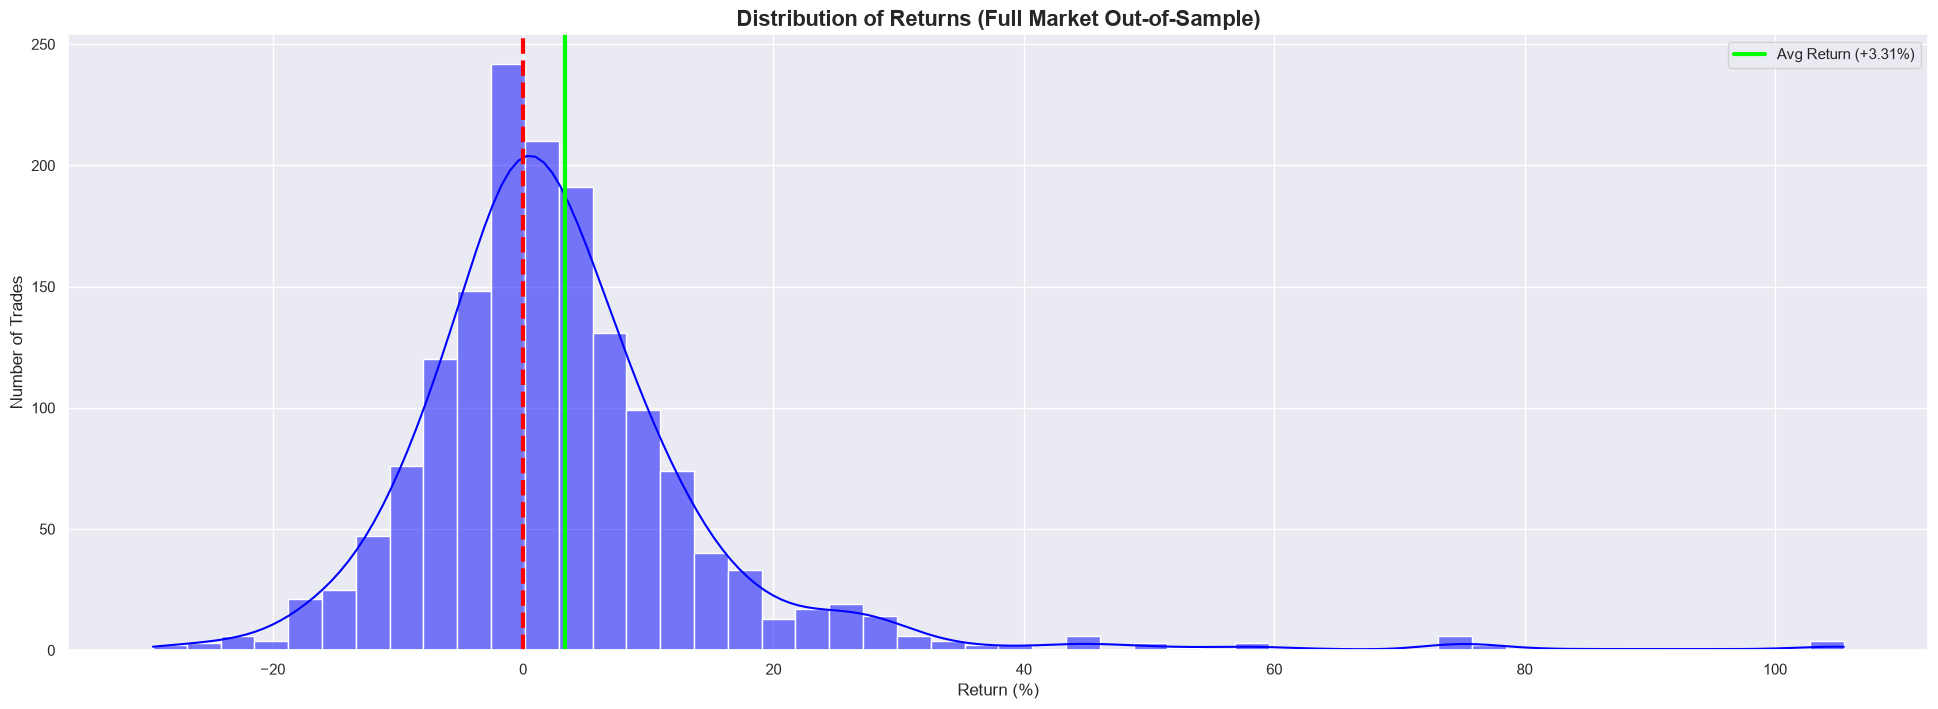

In [4]:
# 4. Full Market Results
total_trades = len(champion_trades)
if total_trades > 0:
    win_rate = (champion_trades['Fwd_Ret'] > 0).mean() * 100
    avg_ret = champion_trades['Fwd_Ret'].mean() * 100
    
    display(HTML(f"<h1 style='color: lime;'>Champion Strategy: Full Market Unseen Backtest</h1>"))
    display(HTML(f"<b>Rules:</b> ER_34 > 0.6 | WMA_Dist < 3% | Hold 13 Days<br>"))
    display(HTML(f"<b>Timeframe:</b> 2023 to Present<br>"))
    display(HTML(f"<hr>"))
    display(HTML(f"<h3>Total Trades Executed: {total_trades}</h3>"))
    display(HTML(f"<h3>Win Rate: {win_rate:.2f}%</h3>"))
    display(HTML(f"<h3>Average Return per Trade: +{avg_ret:.2f}%</h3>"))
    
    # Let's plot the distribution of returns to see if it's skewed by outliers
    plt.figure(figsize=(24, 8))
    sns.histplot(champion_trades['Fwd_Ret'] * 100, bins=50, kde=True, color='blue')
    plt.axvline(0, color='red', linestyle='--', linewidth=3)
    plt.axvline(avg_ret, color='lime', linestyle='-', linewidth=3, label=f'Avg Return (+{avg_ret:.2f}%)')
    plt.title('Distribution of Returns (Full Market Out-of-Sample)', fontsize=16, fontweight='bold')
    plt.xlabel('Return (%)')
    plt.ylabel('Number of Trades')
    plt.legend()
    plt.show()
    
else:
    print("No trades triggered across the entire market.")
